### Objectives

*   Load the finalized cohort (2638 admissions) from 04_Cohort_Construction.ipynb notebook
*   Lock the final feature dictionary - one concept_id per [lthe Zappalà et al. (2025)](https://www.sciencedirect.com/science/article/pii/S0883944125000929) predictor.
*   Extract the raw time-series values scoped to the cohort only (not the full database)
*   Recheck feature completeness and recording density within the cohort
*   Save a feature table for pre-processing.








### Imports and configuration

**Initial BigQuery Setup by Ayushi Kashyap - Adapted for this notebook.**

In [7]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import matplotlib.pyplot as plt

In [8]:
PROJECT_ID         = 'capstoneweaningprediction' #@param {type:"string"}
DATASET_PROJECT_ID = 'amsterdamumcdb'            #@param {type:"string"}
DATASET_ID         = 'version1_5_0'              #@param {type:"string"}
LOCATION           = 'eu'                        #@param {type:"string"}

In [9]:
import os
from google.colab import auth
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
auth.authenticate_user()
print('Authenticated')

Authenticated


In [10]:
%load_ext google.colab.data_table
from google.colab.data_table import DataTable
DataTable.max_columns = 50
DataTable.max_rows    = 80000

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


In [11]:
%load_ext bigquery_magics
from bigquery_magics import bigquery_magics
def_config = bigquery.job.QueryJobConfig(
    default_dataset=DATASET_PROJECT_ID + '.' + DATASET_ID
)
bigquery_magics.context.default_query_job_config = def_config
client = bigquery.Client(
    project=PROJECT_ID, location=LOCATION,
    default_query_job_config=def_config
)
print('BigQuery client ready')

The bigquery_magics extension is already loaded. To reload it, use:
  %reload_ext bigquery_magics
BigQuery client ready


### Section 1: Load the cohort

In [12]:
# Load the cohort built in notebook 04
cohort = pd.read_parquet('/content/sample_data/cohort_zappala.parquet')
print(f"Cohort loaded: {len(cohort):,} admissions")

visit_ids = cohort['visit_occurrence_id'].tolist()

Cohort loaded: 2,638 admissions


In [13]:
cohort.columns

Index(['person_id', 'visit_occurrence_id', 'admission_start', 'admission_end',
       'admission_year', 'age', 'age_bucket', 'gender'],
      dtype='object')

### Section 2: Finalize the feature dictionary

In [14]:
query = f"""
SELECT
    c.concept_id,
    c.concept_name,
    c.domain_id,
    COUNT(DISTINCT m.visit_occurrence_id) AS meas_visits
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
    ON m.measurement_concept_id = c.concept_id
WHERE c.standard_concept = 'S'
  AND (
        LOWER(c.concept_name) LIKE '%heart rate%'
     OR LOWER(c.concept_name) LIKE '%respiratory rate%'
     OR LOWER(c.concept_name) LIKE '%oxygen saturation%'
     OR LOWER(c.concept_name) LIKE '%blood pressure%'
     OR LOWER(c.concept_name) LIKE '%fio2%'
     OR LOWER(c.concept_name) LIKE '%peep%'
     OR LOWER(c.concept_name) LIKE '%tidal volume%'
     OR LOWER(c.concept_name) LIKE '%pao2%'
     OR LOWER(c.concept_name) LIKE '%paco2%'
     OR LOWER(c.concept_name) LIKE '%ph of arterial%'
     OR LOWER(c.concept_name) LIKE '%lactate%'
     OR LOWER(c.concept_name) LIKE '%creatine%'
  )
  AND m.provider_id IS NOT NULL
GROUP BY c.concept_id, c.concept_name, c.domain_id
ORDER BY meas_visits DESC
"""

candidates = client.query(query).to_dataframe()
candidates

,concept_id,concept_name,domain_id,meas_visits
0,21490872,Heart rate.beat-to-beat by EKG,Measurement,23041
1,40762499,Oxygen saturation in Arterial blood by Pulse o...,Measurement,22978
2,42869608,Oxygen saturation [Pure mass fraction] in Blood,Measurement,22414
3,3024171,Respiratory rate,Measurement,21962
4,21490852,Invasive Mean blood pressure,Measurement,21561
5,21490853,Invasive Systolic blood pressure,Measurement,21561
6,21490851,Invasive Diastolic blood pressure,Measurement,21560
7,3007220,Creatine kinase [Enzymatic activity/volume] in...,Measurement,19436
8,3047181,Lactate [Moles/volume] in Blood,Measurement,17330
9,3016436,Lactate dehydrogenase [Enzymatic activity/volu...,Measurement,17121


In [15]:
# One concept_id per feature — picked from the candidates table
# (take the highest meas_visits row that matches each feature).

FEATURE_CONCEPTS = {
    # Vital signs
    'heart_rate':        21490872,   # Heart rate beat-to-beat by EKG
    'respiratory_rate':  3024171,    # Respiratory rate
    'spo2':              40762499,   # Oxygen saturation in Arterial blood by Pulse oximetry

    # Blood pressure
    'systolic_bp':       21490853,   # Invasive Systolic blood pressure
    'mean_bp':           21490852,   # Invasive Mean blood pressure
    'diastolic_bp':      21490851,   # Invasive Diastolic blood pressure

    # Ventilator settings
    'fio2':              3025408,   # Oxygen/Inspired gas Respiratory system by O2 Air
    'peep':              21490855,   # PEEP Respiratory system --on ventilator
    'tidal_volume':      3016166,    # Tidal volume inspired spontaneous+mechanical

    # Blood gases
    'pao2':              3027315,   # Oxygen [Partial pressure] in Blood
    'paco2':             3013290,   # Carbon dioxide [Partial pressure] in Blood
    'ph':                3010421,    # pH of Blood

    # Laboratory
    'lactate':           3047181     # Lactate [Moles/volume] in Blood
}

# Check nothing is left blank
missing = [name for name, cid in FEATURE_CONCEPTS.items() if cid is None]
print("Still need:", missing if missing else "nothing — all locked")

Still need: nothing — all locked


In [16]:
query = f"""
SELECT
    c.concept_id,
    c.concept_name,
    c.domain_id,
    COUNT(DISTINCT m.visit_occurrence_id) AS meas_visits
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
    ON m.measurement_concept_id = c.concept_id
WHERE c.standard_concept = 'S'
  AND (
        LOWER(c.concept_name) LIKE '%inspired oxygen%'
     OR LOWER(c.concept_name) LIKE '%oxygen/inspired%'
     OR LOWER(c.concept_name) LIKE '%oxygen [partial pressure] in arterial%'
     OR LOWER(c.concept_name) LIKE '%carbon dioxide [partial pressure] in arterial%'
     OR LOWER(c.concept_name) LIKE '%ph of arterial blood%'
     OR LOWER(c.concept_name) LIKE '%ph of blood%'
  )
  AND m.provider_id IS NOT NULL
GROUP BY c.concept_id, c.concept_name, c.domain_id
ORDER BY meas_visits DESC
"""

missing_concepts = client.query(query).to_dataframe()
missing_concepts

,concept_id,concept_name,domain_id,meas_visits
0,3010421,pH of Blood,Measurement,22466
1,3025408,Oxygen/Inspired gas Respiratory system by O2 A...,Measurement,15694


In [17]:
query = f"""
SELECT
    c.concept_id,
    c.concept_name,
    COUNT(DISTINCT m.visit_occurrence_id) AS meas_visits
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
    ON m.measurement_concept_id = c.concept_id
WHERE c.standard_concept = 'S'
  AND (
        LOWER(c.concept_name) LIKE '%oxygen%partial pressure%'
     OR LOWER(c.concept_name) LIKE '%carbon dioxide%partial pressure%'
     OR LOWER(c.concept_name) LIKE '%po2%'
     OR LOWER(c.concept_name) LIKE '%pco2%'
  )
  AND LOWER(c.concept_name) LIKE '%blood%'
  AND m.provider_id IS NOT NULL
GROUP BY c.concept_id, c.concept_name
ORDER BY meas_visits DESC
LIMIT 20
"""

client.query(query).to_dataframe()

,concept_id,concept_name,meas_visits
0,3013290,Carbon dioxide [Partial pressure] in Blood,22462
1,3027315,Oxygen [Partial pressure] in Blood,22420


In [18]:
FEATURE_CONCEPTS = {
    # Vital signs
    'heart_rate':        21490872,   # Heart rate beat-to-beat by EKG
    'respiratory_rate':  3024171,    # Respiratory rate
    'spo2':              40762499,   # Oxygen saturation in Arterial blood by Pulse oximetry

    # Blood pressure
    'systolic_bp':       21490853,   # Invasive Systolic blood pressure
    'mean_bp':           21490852,   # Invasive Mean blood pressure
    'diastolic_bp':      21490851,   # Invasive Diastolic blood pressure

    # Ventilator settings
    'fio2':              3025408,    # Oxygen/Inspired gas Respiratory system by O2 Air
    'peep':              21490855,   # PEEP Respiratory system --on ventilator
    'tidal_volume':      3016166,    # Tidal volume inspired spontaneous+mechanical

    # Blood gases
    'pao2':              3027315,    # Oxygen [Partial pressure] in Blood
    'paco2':             3013290,    # Carbon dioxide [Partial pressure] in Blood
    'ph':                3010421,    # pH of Blood

    # Laboratory
    'lactate':           3047181     # Lactate [Moles/volume] in Blood
}

missing = [name for name, cid in FEATURE_CONCEPTS.items() if cid is None]
print("Still need:", missing if missing else "nothing — all locked")

Still need: nothing — all locked


Finalised the concept_ids of features based on the high measurement_visits counts.

### Section 3: Prepare ID lists for the query

AI-assisted (Anthropic Claude Opus 4.8): Generated the code to prepare SQL-compatible visit and concept ID strings.

In [19]:
# Extract the concept_ids out of the dictionary
concept_ids = list(FEATURE_CONCEPTS.values())

# Convert both lists into comma-separated strings for the SQL
visit_ids_str = ",".join(str(v) for v in visit_ids)
concept_ids_str = ",".join(str(c) for c in concept_ids)

print(f"{len(visit_ids)} visit IDs ready")
print(f"{len(concept_ids)} concept IDs ready")
print(f"\nConcept IDs: {concept_ids_str}")

2638 visit IDs ready
13 concept IDs ready

Concept IDs: 21490872,3024171,40762499,21490853,21490852,21490851,3025408,21490855,3016166,3027315,3013290,3010421,3047181


### Section 4: Cohort-scoped extraction query

In [20]:
query = f"""
SELECT
    m.visit_occurrence_id,
    c.concept_name,
    m.measurement_concept_id,
    m.measurement_datetime,
    m.value_as_number
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
    ON m.measurement_concept_id = c.concept_id
WHERE m.visit_occurrence_id IN ({visit_ids_str}) # Restrict to the cohort
  AND m.measurement_concept_id IN ({concept_ids_str}) # Restrict to the features
  AND m.provider_id IS NOT NULL
  AND m.value_as_number IS NOT NULL
"""

feature_long = client.query(query).to_dataframe()
feature_long.head()

,visit_occurrence_id,concept_name,measurement_concept_id,measurement_datetime,value_as_number
0,813,Oxygen saturation in Arterial blood by Pulse o...,40762499,2013-01-01 00:36:00+00:00,1.00000000000000000000000000000000000000
1,627,Oxygen saturation in Arterial blood by Pulse o...,40762499,2013-01-06 05:03:00+00:00,5.00000000000000000000000000000000000000
2,523,Oxygen saturation in Arterial blood by Pulse o...,40762499,2013-01-18 00:47:00+00:00,22.00000000000000000000000000000000000000
3,414,Oxygen saturation in Arterial blood by Pulse o...,40762499,2013-01-02 06:22:00+00:00,24.00000000000000000000000000000000000000
4,1239,Oxygen saturation in Arterial blood by Pulse o...,40762499,2013-01-25 23:36:00+00:00,25.00000000000000000000000000000000000000


A dataframe containing every recorded measurement of the selected physiological variables for every ICU admission in the selected cohort.

### Section 5: Basic Sanity Checks

In [21]:
print(f"Total rows: {len(feature_long):,}")
print(f"Unique visits covered: {feature_long['visit_occurrence_id'].nunique():,} / {len(visit_ids):,}")
print()
print("Observations per feature:")
print(feature_long['concept_name'].value_counts())

Total rows: 6,223,917
Unique visits covered: 2,638 / 2,638

Observations per feature:
concept_name
Tidal volume inspired spontaneous+mechanical Measured --on ventilator    924658
Heart rate.beat-to-beat by EKG                                           693481
Invasive Systolic blood pressure                                         666235
Invasive Diastolic blood pressure                                        666143
Invasive Mean blood pressure                                             666069
Oxygen saturation in Arterial blood by Pulse oximetry                    661472
PEEP Respiratory system --on ventilator                                  462404
Oxygen/Inspired gas Respiratory system by O2 Analyzer --on ventilator    458111
Respiratory rate                                                         285552
Carbon dioxide [Partial pressure] in Blood                               221003
Oxygen [Partial pressure] in Blood                                       218225
pH of Blood          

The query extracted 6.22 million physiological measurements from all 2,638 ICU admissions, with tidal volume, heart rate, blood pressure, and oxygen saturation being the most frequently recorded variables.

### Section 6: Cohort-scoped completeness check

In [22]:
coverage = (
    feature_long.groupby('concept_name')
    .agg(
        n_visits=('visit_occurrence_id', 'nunique'),
        n_obs=('value_as_number', 'count')
    )
    .reset_index()
)

coverage['pct_cohort_covered'] = 100 * coverage['n_visits'] / len(visit_ids)
coverage = coverage.sort_values('pct_cohort_covered', ascending=False)
coverage

,concept_name,n_visits,n_obs,pct_cohort_covered
0,Carbon dioxide [Partial pressure] in Blood,2638,221003,100.000000
1,Heart rate.beat-to-beat by EKG,2638,693481,100.000000
12,pH of Blood,2638,214975,100.000000
7,Oxygen saturation in Arterial blood by Pulse o...,2638,661472,100.000000
6,Oxygen [Partial pressure] in Blood,2638,218225,100.000000
4,Invasive Systolic blood pressure,2637,666235,99.962092
3,Invasive Mean blood pressure,2637,666069,99.962092
2,Invasive Diastolic blood pressure,2637,666143,99.962092
8,Oxygen/Inspired gas Respiratory system by O2 A...,2636,458111,99.924185
11,Tidal volume inspired spontaneous+mechanical M...,2634,924658,99.848370


All selected physiological variables are available for appox evey ICU admission in the cohort.

Section 7: Per-visit recording density

In [23]:
# Count observations per visit, per feature
density = (
    feature_long.groupby(['visit_occurrence_id', 'concept_name'])
    .size()
    .reset_index(name='n_obs')
)

# Summary statistics of that count, per feature
density_summary = density.groupby('concept_name')['n_obs'].describe()
density_summary

,count,mean,std,min,25%,50%,75%,max
concept_name,,,,,,,,
Carbon dioxide [Partial pressure] in Blood,2638.0,83.776725,84.359892,4.0,33.0,57.0,101.75,1345.0
Heart rate.beat-to-beat by EKG,2638.0,262.881350,304.502430,23.0,86.0,160.5,323.75,5483.0
Invasive Diastolic blood pressure,2637.0,252.613955,295.566762,13.0,81.0,156.0,308.00,5443.0
Invasive Mean blood pressure,2637.0,252.585893,295.546010,13.0,82.0,156.0,308.00,5443.0
Invasive Systolic blood pressure,2637.0,252.648843,295.609466,13.0,82.0,156.0,308.00,5444.0
Lactate [Moles/volume] in Blood,2594.0,32.994988,48.036121,1.0,6.0,13.0,40.75,397.0
Oxygen [Partial pressure] in Blood,2638.0,82.723654,83.458962,4.0,33.0,56.0,100.00,1316.0
Oxygen saturation in Arterial blood by Pulse oximetry,2638.0,250.747536,293.635917,14.0,82.0,152.0,310.75,5380.0
Oxygen/Inspired gas Respiratory system by O2 Analyzer --on ventilator,2636.0,173.790212,230.302363,1.0,45.0,95.0,210.25,5246.0


In [24]:
cohort.columns.tolist()

['person_id',
 'visit_occurrence_id',
 'admission_start',
 'admission_end',
 'admission_year',
 'age',
 'age_bucket',
 'gender']

AI-assisted: observation density calculation suggested by Claude, Anthropic — Claude Opus 4.8

In [31]:
# Bring in each admission's ventilation duration to normalize by stay length
# The 'imv_duration_hours' column is missing from the cohort DataFrame.
# Calculating admission duration as a proxy for stay length.
dur = cohort[['visit_occurrence_id', 'admission_start', 'admission_end']].copy()
dur['imv_duration_hours'] = (dur['admission_end'] - dur['admission_start']).dt.total_seconds() / 3600
dur = dur[['visit_occurrence_id', 'imv_duration_hours']]

# Ensure visit_occurrence_id has the same type in both dataframes for robust merging
density['visit_occurrence_id'] = density['visit_occurrence_id'].astype(int)
dur['visit_occurrence_id'] = dur['visit_occurrence_id'].astype(int)

density = density.merge(dur, on='visit_occurrence_id', how='left')
density['obs_per_hour'] = density['n_obs'] / density['imv_duration_hours']

# Median observations per hour, per feature — the grid-resolution signal
obs_per_hour = (
    density.groupby('concept_name')['obs_per_hour']
    .median()
    .sort_values(ascending=False)
)
obs_per_hour

,obs_per_hour
concept_name,
Tidal volume inspired spontaneous+mechanical Measured --on ventilator,1.276867
Heart rate.beat-to-beat by EKG,0.920617
Invasive Diastolic blood pressure,0.909091
Invasive Systolic blood pressure,0.908972
Invasive Mean blood pressure,0.908927
Oxygen saturation in Arterial blood by Pulse oximetry,0.865247
PEEP Respiratory system --on ventilator,0.638433
Oxygen/Inspired gas Respiratory system by O2 Analyzer --on ventilator,0.630960
Respiratory rate,0.357557


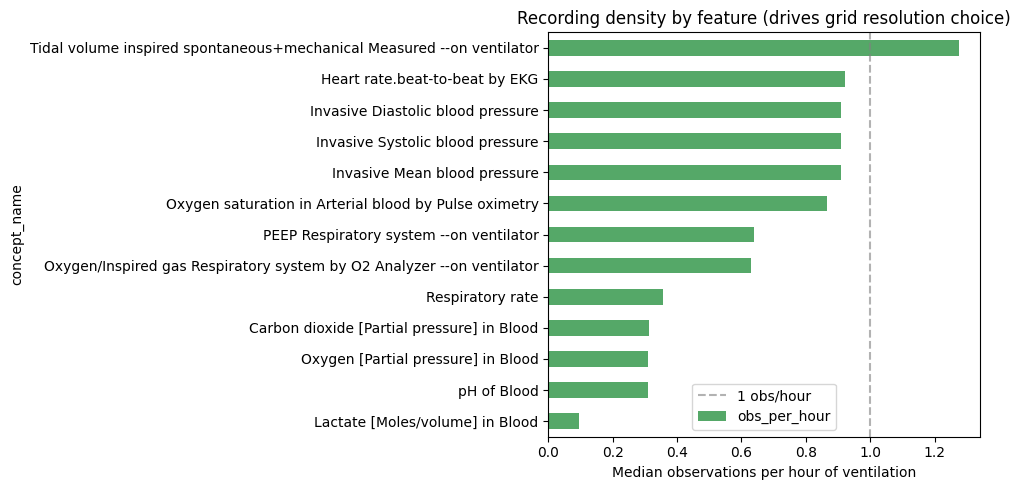

In [32]:
plt.figure(figsize=(10, 5))
obs_per_hour.plot(kind='barh', color='#55A868')
plt.xlabel('Median observations per hour of ventilation')
plt.title('Recording density by feature (drives grid resolution choice)')
plt.axvline(1, color='grey', linestyle='--', alpha=0.6, label='1 obs/hour')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Filter feature_long to get heart rate measurements
hr = feature_long[feature_long['measurement_concept_id'] == FEATURE_CONCEPTS['heart_rate']].copy()

hr['measurement_datetime'] = pd.to_datetime(hr['measurement_datetime'])
hr_sorted = hr.sort_values(['visit_occurrence_id', 'measurement_datetime'])
hr_sorted['gap_min'] = (hr_sorted.groupby('visit_occurrence_id')['measurement_datetime']
                        .diff().dt.total_seconds() / 60)

print(hr_sorted['gap_min'].describe())
print("\nMost common gaps (minutes):")
print(hr_sorted['gap_min'].round().value_counts().head(10))

count    690843.000000
mean         68.298994
std          39.701275
min           1.000000
25%          60.000000
50%          60.000000
75%          60.000000
max        9720.000000
Name: gap_min, dtype: float64

Most common gaps (minutes):
gap_min
60.0     584079
120.0     78183
180.0      2537
30.0       2074
59.0       1908
61.0       1562
240.0      1519
15.0        749
45.0        639
40.0        554
Name: count, dtype: int64


AI-assisted: measurement gap analysis assisted by Claude, Anthropic — Claude Opus 4.8

In [30]:
feature_long['measurement_datetime'] = pd.to_datetime(feature_long['measurement_datetime'])

# Gap between consecutive readings, within each visit, per feature
fl = feature_long.sort_values(['concept_name', 'visit_occurrence_id', 'measurement_datetime'])
fl['gap_min'] = (fl.groupby(['concept_name', 'visit_occurrence_id'])['measurement_datetime']
                 .diff().dt.total_seconds() / 60)

# For each feature: the most common gap (the mode) and the median
gap_summary = (fl.groupby('concept_name')['gap_min']
               .agg(median_gap='median',
                    modal_gap=lambda s: s.round().mode().iloc[0] if len(s.dropna()) else None))
gap_summary.sort_values('median_gap')

,median_gap,modal_gap
concept_name,,
Tidal volume inspired spontaneous+mechanical Measured --on ventilator,0.0,0.0
Heart rate.beat-to-beat by EKG,60.0,60.0
Invasive Mean blood pressure,60.0,60.0
Invasive Diastolic blood pressure,60.0,60.0
Oxygen saturation in Arterial blood by Pulse oximetry,60.0,60.0
PEEP Respiratory system --on ventilator,60.0,60.0
Oxygen/Inspired gas Respiratory system by O2 Analyzer --on ventilator,60.0,60.0
Invasive Systolic blood pressure,60.0,60.0
Respiratory rate,60.0,60.0


In [33]:
tv = feature_long[feature_long['concept_name'].str.contains('Tidal volume')].copy()

# Pick one visit, look at a chunk of readings with their timestamps
one = tv[tv['visit_occurrence_id'] == tv['visit_occurrence_id'].iloc[0]].sort_values('measurement_datetime')
print(one[['measurement_datetime', 'value_as_number']].head(20))

# How many readings share an identical timestamp within a visit?
dupes = tv.groupby(['visit_occurrence_id', 'measurement_datetime']).size()
print("\nReadings per (visit, timestamp):")
print(dupes.describe())
print("\nHow often is there more than 1 value at the same timestamp?",
      f"{(dupes > 1).mean()*100:.1f}% of timestamps")

            measurement_datetime                              value_as_number
585423 2013-01-01 01:10:00+00:00  1727.00000000000000000000000000000000000000
585422 2013-01-01 01:10:00+00:00  1727.00000000000000000000000000000000000000
570987 2013-01-01 01:22:00+00:00   553.00000000000000000000000000000000000000
570986 2013-01-01 01:22:00+00:00   553.00000000000000000000000000000000000000
577635 2013-01-01 02:22:00+00:00   630.00000000000000000000000000000000000000
577634 2013-01-01 02:22:00+00:00   630.00000000000000000000000000000000000000
552658 2013-01-01 03:22:00+00:00   459.00000000000000000000000000000000000000
552659 2013-01-01 03:22:00+00:00   459.00000000000000000000000000000000000000
546196 2013-01-01 03:42:00+00:00   437.00000000000000000000000000000000000000
546199 2013-01-01 03:42:00+00:00   437.00000000000000000000000000000000000000
559507 2013-01-01 04:22:00+00:00   485.00000000000000000000000000000000000000
559509 2013-01-01 04:22:00+00:00   485.0000000000000000000000000

#### Remove Duplicates

In [34]:
# Tidal volume (and possibly others) has exact duplicate rows —
# same visit, same concept, same timestamp, same value, recorded twice.
before = len(feature_long)

feature_long = feature_long.drop_duplicates(
    subset=['visit_occurrence_id', 'measurement_concept_id', 'measurement_datetime', 'value_as_number']
)

after = len(feature_long)
print(f"Removed {before - after:,} duplicate rows ({before:,} → {after:,})")

Removed 462,572 duplicate rows (6,223,917 → 5,761,345)


In [35]:
# Confirm tidal volume is now on a 60-min cadence like the other vitals,
# and nothing else changed.
feature_long['measurement_datetime'] = pd.to_datetime(feature_long['measurement_datetime'])

fl = feature_long.sort_values(['concept_name', 'visit_occurrence_id', 'measurement_datetime'])
fl['gap_min'] = (fl.groupby(['concept_name', 'visit_occurrence_id'])['measurement_datetime']
                 .diff().dt.total_seconds() / 60)

check = (fl.groupby('concept_name')['gap_min']
         .agg(median_gap='median',
              modal_gap=lambda s: s.round().mode().iloc[0] if len(s.dropna()) else None))
print(check.sort_values('median_gap'))

/tmp/ipykernel_5489/2840897354.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_long['measurement_datetime'] = pd.to_datetime(feature_long['measurement_datetime'])


                                                    median_gap  modal_gap
concept_name                                                             
Heart rate.beat-to-beat by EKG                            60.0       60.0
Invasive Diastolic blood pressure                         60.0       60.0
Invasive Mean blood pressure                              60.0       60.0
Invasive Systolic blood pressure                          60.0       60.0
Oxygen saturation in Arterial blood by Pulse ox...        60.0       60.0
Respiratory rate                                          60.0       60.0
PEEP Respiratory system --on ventilator                   60.0       60.0
Oxygen/Inspired gas Respiratory system by O2 An...        60.0       60.0
Tidal volume inspired spontaneous+mechanical Me...        60.0       60.0
Carbon dioxide [Partial pressure] in Blood               187.0        0.0
Oxygen [Partial pressure] in Blood                       188.0        0.0
pH of Blood                           

### Section 8: Save the data

In [36]:
import json

# Save the deduplicated long-format table
feature_long.to_parquet('cohort_features_long.parquet', index=False)

# Save metadata so notebook 06 inherits the feature dict, target/context split, and grid decision
metadata = {
    'feature_concepts': FEATURE_CONCEPTS,
    'targets': [
        'heart_rate', 'respiratory_rate', 'spo2',
        'systolic_bp', 'mean_bp', 'diastolic_bp',
        'fio2', 'peep', 'tidal_volume'
    ],
    'context_only': ['pao2', 'paco2', 'ph', 'lactate'],
    'grid_resolution': 'hourly',
    'n_admissions': int(feature_long['visit_occurrence_id'].nunique()),
    'notes': (
        'Vitals and ventilator settings recorded at ~hourly cadence (modal gap 60 min) '
        'in AmsterdamUMCdb v1.5.0 OMOP extract. Tidal volume deduplicated (recorded 2x per '
        'timestamp in source). Blood gases and lactate irregular (~3h to daily), context-only.'
    )
}

with open('feature_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved {len(feature_long):,} rows to cohort_features_long.parquet")
print(f"Covering {metadata['n_admissions']:,} admissions")
print("Saved feature_metadata.json")

Saved 5,761,345 rows to cohort_features_long.parquet
Covering 2,638 admissions
Saved feature_metadata.json
